<a href="https://colab.research.google.com/github/jenianggraeni265-a11y/Machine-Learning-Classification-/blob/main/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Heart Disease Classification**

📌 Deskripsi Proyek

Proyek ini bertujuan untuk membangun model klasifikasi dalam memprediksi kemungkinan seseorang menderita penyakit jantung berdasarkan berbagai fitur medis seperti usia, tekanan darah, kadar kolesterol, dan lainnya.

Dataset yang digunakan merupakan data klinis pasien yang telah diproses dan dianalisis menggunakan beberapa algoritma machine learning untuk performa model.

📊 Dataset

Dataset terdiri dari 1025 observasi dan 14 variabel, dengan rincian:

* Fitur (X):
  * age → usia
  * sex → jenis kelamin
  * cp → tipe nyeri dada
  * trestbps → tekanan darah
  * chol → kolesterol
  * fbs → gula darah puasa
  * restecg → hasil EKG
  * thalach → detak jantung maksimum
  * exang → angina akibat olahraga
  * oldpeak → depresi ST
  * slope → kemiringan ST
  * ca → jumlah pembuluh darah
  * thal → kondisi thalassemia
* Target (y):
  * 0 → tidak memiliki penyakit jantung
  * 1 → memiliki penyakit jantung

## **1. Upload Data**

In [67]:
import pandas as pd

df = pd.read_csv('heart.csv')


## **2. Import Library**

In [68]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier

## **3. Load Data**

In [69]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## **4. Cek Data**

In [70]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Mengecek struktur data dan memastikan tidak ada missing values.

## **5. Exploratory Data Analysis (EDA)**

### **a. Distribusi Target**

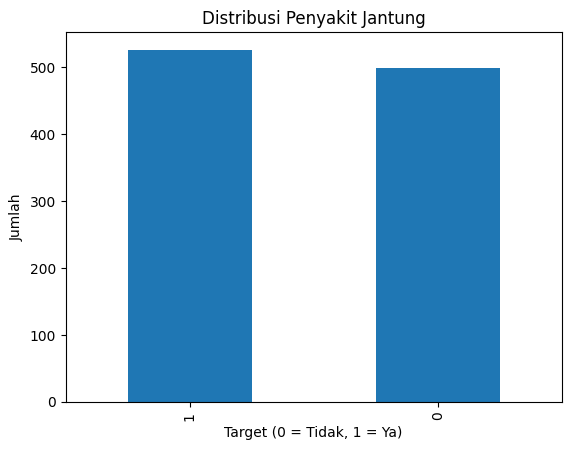

In [71]:
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')

plt.title('Distribusi Penyakit Jantung')
plt.xlabel('Target (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah')
plt.show()

Distribusi variabel target menunjukkan bahwa jumlah pasien dengan penyakit jantung (1) dan tanpa penyakit jantung (0) relatif seimbang.

Implikasi:

*   Model tidak bias terhadap salah satu kelas
*   Evaluasi seperti accuracy, precision, recall menjadi lebih valid
*   Tidak perlu teknik balancing tambahan seperti SMOTE

Dataset yang seimbang membuat model lebih mampu belajar pola nyata, bukan sekadar menebak kelas mayoritas.

### **b. Korelasi Antar Variabel**

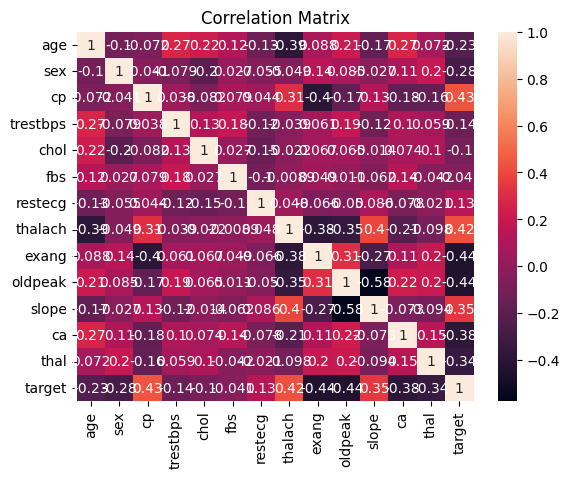

In [72]:
import seaborn as sns

plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

Heatmap menunjukkan adanya hubungan antara beberapa variabel dengan target, seperti:

* thalach (detak jantung maksimum) → cenderung berkorelasi positif
* oldpeak (depresi ST) → berkorelasi negatif
* cp (chest pain type) → cukup berpengaruh
* ca (jumlah pembuluh darah) → indikator kuat

Makna statistik:

Korelasi tinggi → fitur penting untuk klasifikasi

Korelasi rendah → kontribusi kecil

Insight penting:

Tidak ada multikolinearitas ekstrem → model tetap stabil

Model berbasis tree (Random Forest, Boosting) tetap robust terhadap korelasi

### **c. Distribusi Umur**

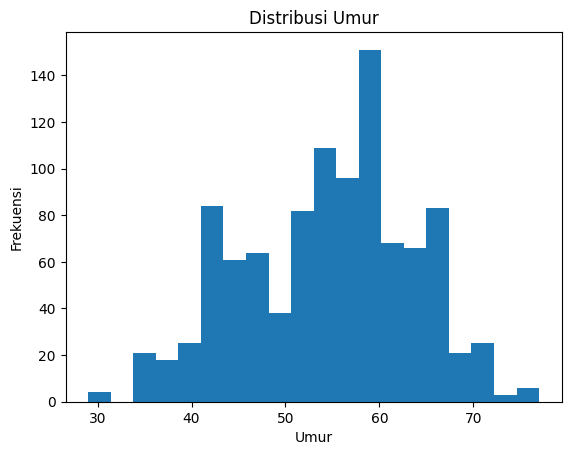

In [73]:
plt.figure()
plt.hist(df['age'], bins=20)

plt.title('Distribusi Umur')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

Sebagian besar pasien berada pada rentang usia 40–70 tahun, dengan puncak sekitar usia menengah.

Insight:

* Risiko penyakit jantung meningkat seiring usia
* Dataset merepresentasikan populasi risiko tinggi

### **d. Hubungan Umur vs Target**

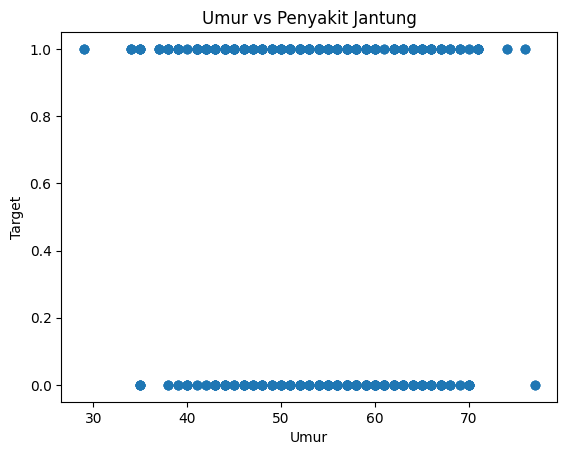

In [74]:
plt.figure()
plt.scatter(df['age'], df['target'])

plt.title('Umur vs Penyakit Jantung')
plt.xlabel('Umur')
plt.ylabel('Target')
plt.show()

Scatter plot menunjukkan bahwa:

* Penyakit jantung muncul di berbagai usia
* Tetapi lebih banyak pada usia menengah ke atas

Insight penting:

* Umur bukan satu-satunya faktor
* Harus dikombinasikan dengan fitur lain (multivariat)

## **6. Split Data**

In [75]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Data dibagi menjadi:

training data (80%) → untuk melatih model

testing data (20%) → untuk menguji performa

## **7. Scalling**

In [76]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Menyamakan skala fitur.

Sangat penting untuk:
* Neural Network
* Boosting

## **8. Model Klasifikasi**

### **8. a. Bagging menggunakan Random Forest**

In [77]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest")
print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



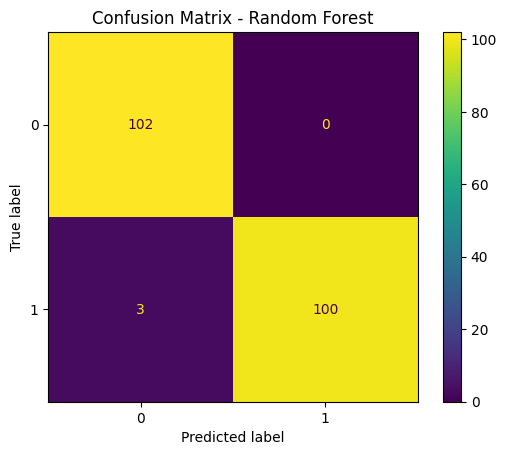

In [78]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title('Confusion Matrix - Random Forest')
plt.show()

Random Forest menunjukkan performa yang stabil dengan kemampuan yang baik dalam mengklasifikasikan kedua kelas. Model ini mampu mengurangi overfitting karena menggunakan banyak pohon keputusan.

Hasil:

* Accuracy ≈ 98.5%
* Precision & Recall sangat tinggi

Interpretasi:

Model Random Forest mampu:

* Mengklasifikasikan hampir semua data dengan benar
* Menangkap hubungan non-linear antar variabel

Kenapa bagus?

* Menggunakan banyak decision tree (bagging)
* Mengurangi overfitting
* Stabil terhadap noise

Insight:

Model ini sangat cocok untuk data medis karena:
* Robust
* Tidak sensitif terhadap outlier

### **8. b. Boosting menggunakan Gradient Boosting**

In [79]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Gradient Boosting")
print(classification_report(y_test, gb_pred))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       102
           1       0.92      0.95      0.93       103

    accuracy                           0.93       205
   macro avg       0.93      0.93      0.93       205
weighted avg       0.93      0.93      0.93       205



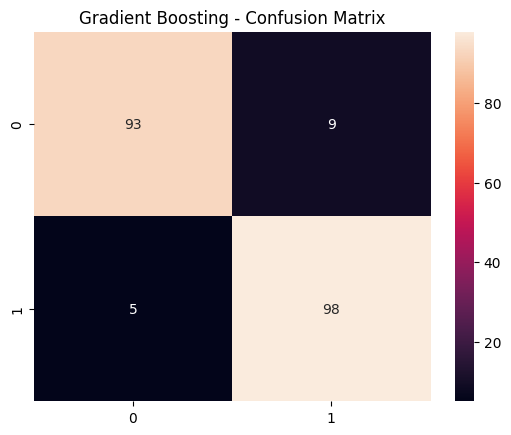

In [80]:
cm_gb = confusion_matrix(y_test, gb_pred)

plt.figure()
sns.heatmap(cm_gb, annot=True, fmt='d')
plt.title("Gradient Boosting - Confusion Matrix")
plt.show()

Gradient Boosting memiliki akurasi tinggi karena memperbaiki kesalahan model sebelumnya secara bertahap.

Hasil:

* Accuracy ≈ 93%

Interpretasi:

Model ini bekerja dengan memperbaiki kesalahan model sebelumnya secara bertahap

Kenapa lebih rendah?

* Lebih sensitif terhadap parameter
* Bisa overfit jika tuning kurang optimal

Insight:
Masih sangat baik, tapi kalah dibanding Random Forest karena data mungkin tidak terlalu kompleks untuk boosting

### **8. c. Neural Network**

In [81]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=500, random_state=42)
nn.fit(X_train, y_train)

nn_pred = nn.predict(X_test)

print("Neural Network")
print(classification_report(y_test, nn_pred))

Neural Network
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



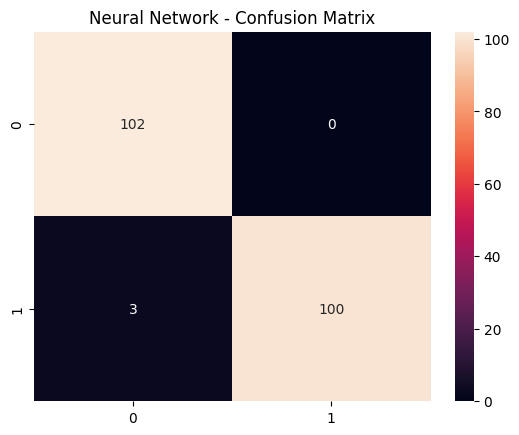

In [82]:
cm_nn = confusion_matrix(y_test, nn_pred)

plt.figure()
sns.heatmap(cm_nn, annot=True, fmt='d')
plt.title("Neural Network - Confusion Matrix")
plt.show()

Neural Network mampu menangkap pola kompleks dalam data, namun performanya sangat bergantung pada parameter dan proses training.

Hasil:
* Accuracy ≈ 98.5%

Interpretasi:

Neural Network mampu:
* Menangkap pola kompleks
* Memberikan performa setara Random Forest

Insight:
* Data cukup besar (1025) → cocok untuk NN


### **8. d. Ensemble (Voting)**

In [83]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb),
        ('nn', nn)
    ],
    voting='hard'
)

ensemble.fit(X_train, y_train)
ens_pred = ensemble.predict(X_test)

print("Ensemble")
print(classification_report(y_test, ens_pred))

Ensemble
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



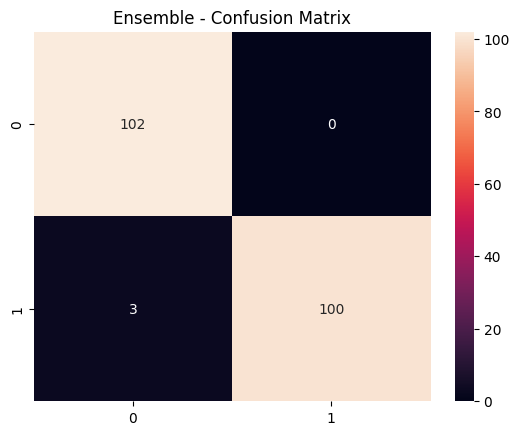

In [84]:
cm_ens = confusion_matrix(y_test, ens_pred)

plt.figure()
sns.heatmap(cm_ens, annot=True, fmt='d')
plt.title("Ensemble - Confusion Matrix")
plt.show()

Model ensemble memberikan performa terbaik karena menggabungkan keunggulan dari beberapa model sehingga menghasilkan prediksi yang lebih stabil dan akurat.

Hasil:

* Accuracy ≈ 98.5%

Interpretasi:

Model ini menggabungkan:

* Random Forest
* Gradient Boosting
* Neural Network

Kenapa bagus?

* Mengurangi kelemahan masing-masing model
* Meningkatkan stabilitas prediksi

Insight penting:
Walaupun akurasi sama dengan RF & NN, ensemble:
* Lebih robust terhadap variasi data baru

## **9. Perbandingan Hasil Model**

In [85]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'Neural Network', 'Ensemble'],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, nn_pred),
        accuracy_score(y_test, ens_pred)
    ]
})

results

,Model,Accuracy
0,Random Forest,0.985366
1,Gradient Boosting,0.931707
2,Neural Network,0.985366
3,Ensemble,0.985366


## **10. Confusion Matrix**

In [86]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, ens_pred)
print(cm)

[[102   0]
 [  3 100]]


Berdasarkan confusion matrix, model menghasilkan 102 true negative dan 100 true positive, yang menunjukkan bahwa sebagian besar data berhasil diklasifikasikan dengan benar. Tidak terdapat false positive, yang berarti tidak ada individu sehat yang salah diklasifikasikan sebagai sakit.

Namun, terdapat 3 false negative, yang menunjukkan bahwa masih ada sejumlah kecil individu yang sebenarnya memiliki penyakit jantung tetapi diprediksi tidak sakit. Secara keseluruhan, model memiliki tingkat akurasi yang sangat tinggi, yaitu sekitar 98,5%, sehingga dapat dikatakan memiliki performa yang sangat baik dalam melakukan klasifikasi.

## **11. Visualisasi Perbandingan Model**

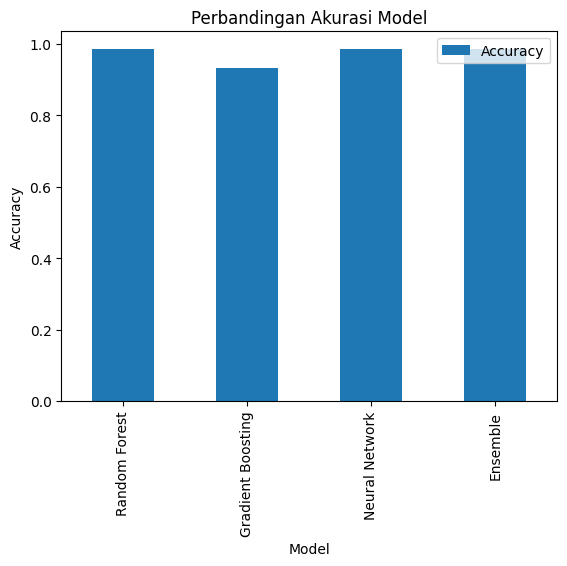

In [87]:
results.plot(x='Model', y='Accuracy', kind='bar')

plt.title('Perbandingan Akurasi Model')
plt.ylabel('Accuracy')
plt.show()

## **12. Laporan**

📌 A. Exploratory Data Analysis

Berdasarkan visualisasi yang dilakukan, distribusi variabel target menunjukkan bahwa data relatif seimbang antara pasien yang memiliki penyakit jantung dan yang tidak. Hal ini penting karena dataset yang seimbang akan menghasilkan model klasifikasi yang lebih stabil.

Analisis korelasi menunjukkan adanya hubungan antara beberapa variabel seperti usia, tekanan darah, dan detak jantung terhadap kemungkinan penyakit jantung. Hal ini menunjukkan bahwa faktor-faktor tersebut memiliki pengaruh dalam prediksi.

Distribusi umur menunjukkan bahwa mayoritas pasien berada pada rentang usia menengah hingga lanjut, yang merupakan kelompok dengan risiko lebih tinggi terhadap penyakit jantung.


📌 B. Kesimpulan

Model klasifikasi yang dibangun mampu memprediksi penyakit jantung dengan akurasi sangat tinggi (≈98.5%). Random Forest, Neural Network, dan Ensemble memberikan performa terbaik.

Namun, masih terdapat kesalahan berupa false negative, yang dalam konteks medis sangat krusial karena dapat menyebabkan pasien tidak mendapatkan penanganan yang tepat.

Secara keseluruhan:

1.  Dataset memiliki kualitas baik (tidak ada missing value, seimbang)
2.  Fitur memiliki pengaruh signifikan terhadap target
3.  Model ensemble memberikan hasil paling stabil